<a href="https://colab.research.google.com/github/wlodarskajulia/NLP_assignment_3/blob/master/slice_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Slice evaluation

Authors: Julia Wlodarska (S5965780), Lara van den Broek (S5883288), Tessa van Staalduinen (S5999286)

This notebook implements the following slice evaluations: Length Buckets and Input Field Stress Test.

Note: Model was trained on Google Colab (T4 GPU)

# Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
)

# Load model and tokenizer

In [ ]:
MODEL_PATH = "./distilbert_agnews"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Device: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Device: cuda


In [ ]:
# Dataset class
class AGNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long),
        }

# Load and split data

In [ ]:
# Load and split data (same split as training)
splits = {"train": "train.jsonl", "test": "test.jsonl"}
df_train = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["train"], lines=True)
test_df  = pd.read_json("hf://datasets/sh0416/ag_news/" + splits["test"],  lines=True)

# Labels (zero-indexed)
y_test = (test_df["label"] - 1).tolist()

print(f"Test set size: {len(test_df)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Test set size: 7600


In [ ]:
def get_predictions(texts, labels, max_length=64):
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
    )
    dataset = AGNewsDataset(encodings, labels)

    # Use Trainer just for prediction
    trainer = Trainer(model=model)
    predictions = trainer.predict(dataset)
    preds = np.argmax(predictions.predictions, axis=-1)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="macro")
    return preds, acc, f1

# Slice 1: Length buckets

In [ ]:
X_test_full = (test_df["title"] + " " + test_df["description"]).tolist()

lengths = [
    len(tokenizer(text, truncation=True, max_length=64)["input_ids"])
    for text in X_test_full
]
test_df["length"] = lengths

# Define bins
bins   = [0, 30, 50, float("inf")]
labels_bins = ["Short (<30)", "Medium (30–50)", "Long (>50)"]
test_df["bucket"] = pd.cut(test_df["length"], bins=bins, labels=labels_bins)

print(test_df["bucket"].value_counts().sort_index())

bucket
Short (<30)        335
Medium (30–50)    3471
Long (>50)        3794
Name: count, dtype: int64


## Evaluate

In [ ]:
bucket_results = []

for bucket in labels_bins:
    subset = test_df[test_df["bucket"] == bucket]
    texts  = (subset["title"] + " " + subset["description"]).tolist()
    labels = (subset["label"] - 1).tolist()

    _, acc, f1 = get_predictions(texts, labels)
    bucket_results.append({
        "Bucket":   bucket,
        "N":        len(subset),
        "Accuracy": round(acc, 4),
        "Macro-F1": round(f1, 4),
    })

results_df = pd.DataFrame(bucket_results)
print(results_df.to_string(index=False))

        Bucket    N  Accuracy  Macro-F1
   Short (<30)  335    0.8746    0.8696
Medium (30–50) 3471    0.9401    0.9381
    Long (>50) 3794    0.9504    0.9513


## Plot results

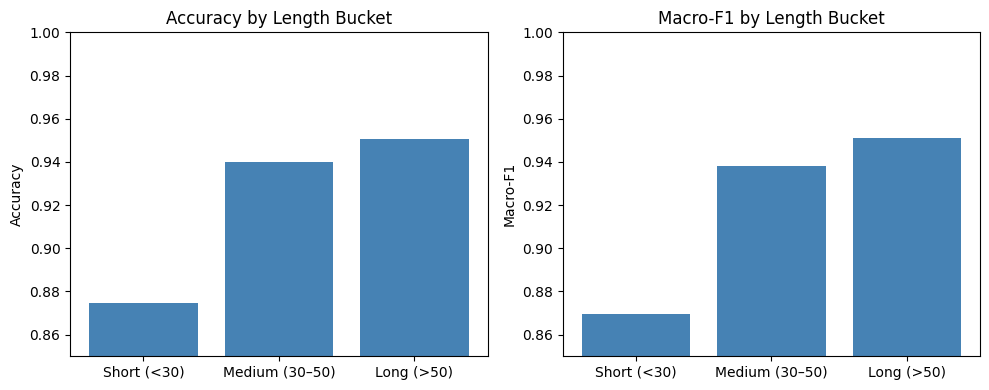

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(results_df["Bucket"], results_df["Accuracy"], color="steelblue")
axes[0].set_title("Accuracy by Length Bucket")
axes[0].set_ylim(0.85, 1.0)
axes[0].set_ylabel("Accuracy")

axes[1].bar(results_df["Bucket"], results_df["Macro-F1"], color="steelblue")
axes[1].set_title("Macro-F1 by Length Bucket")
axes[1].set_ylim(0.85, 1.0)
axes[1].set_ylabel("Macro-F1")

plt.tight_layout()
plt.show()

# Slice 2: Input Field Stress Test

In [ ]:
# Condition 1: title + description (baseline)
texts_full    = (test_df["title"] + " " + test_df["description"]).tolist()
# Condition 2: title only
texts_title   = test_df["title"].tolist()

_, acc_full,  f1_full  = get_predictions(texts_full,  y_test)
_, acc_title, f1_title = get_predictions(texts_title, y_test)

stress_results = pd.DataFrame([
    {"Condition": "Title + Description", "Accuracy": round(acc_full,  4), "Macro-F1": round(f1_full,  4)},
    {"Condition": "Title Only",          "Accuracy": round(acc_title, 4), "Macro-F1": round(f1_title, 4)},
])

print(stress_results.to_string(index=False))

          Condition  Accuracy  Macro-F1
Title + Description    0.9424    0.9424
         Title Only    0.8061    0.8057


## Plot results

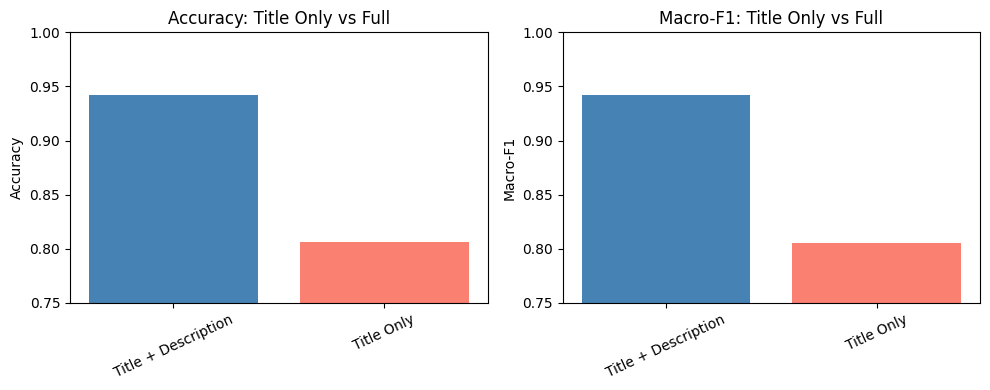

In [ ]:
stress_results = stress_results.reset_index(drop=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Accuracy
axes[0].bar(stress_results["Condition"], stress_results["Accuracy"], color=["steelblue", "salmon"])
axes[0].set_title("Accuracy: Title Only vs Full")
axes[0].set_ylim(0.75, 1.0)
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis='x', rotation=25)

# Macro-F1
axes[1].bar(stress_results["Condition"], stress_results["Macro-F1"], color=["steelblue", "salmon"])
axes[1].set_title("Macro-F1: Title Only vs Full")
axes[1].set_ylim(0.75, 1.0)
axes[1].set_ylabel("Macro-F1")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()